In [147]:
#customer lifetime value prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [148]:
df = pd.read_csv('online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Loaded {len(df)} transactions")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique()}")

Loaded 397484 transactions
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4332


In [149]:
# 1. create enhanced customer features

print("Creating customer features...")

customer_features = df.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max'],           # First and last purchase
    'InvoiceNo': 'nunique',                  # Frequency
    'Quantity': ['sum', 'mean'],             # Total items, avg items per transaction
    'UnitPrice': 'mean',                     # Avg price point
    'TotalPrice': ['sum', 'mean', 'std']     # Monetary metrics
}).reset_index()

customer_features.columns = [
    'CustomerID', 
    'first_purchase', 
    'last_purchase', 
    'frequency',
    'total_quantity', 
    'avg_quantity',
    'avg_unit_price', 
    'total_spent', 
    'avg_transaction', 
    'std_transaction'
]

Creating customer features...


In [150]:
customer_features['first_purchase'] = pd.to_datetime(customer_features['first_purchase'])
customer_features['last_purchase'] = pd.to_datetime(customer_features['last_purchase'])

print(f"Created features for {len(customer_features)} customers")
print("\nFirst 5 rows:")
print(customer_features.head())

Created features for 4332 customers

First 5 rows:
   CustomerID      first_purchase       last_purchase  frequency  \
0     12347.0 2010-12-07 14:57:00 2011-12-07 15:52:00          7   
1     12348.0 2010-12-16 19:09:00 2011-09-25 13:13:00          4   
2     12349.0 2011-11-21 09:51:00 2011-11-21 09:51:00          1   
3     12350.0 2011-02-02 16:01:00 2011-02-02 16:01:00          1   
4     12352.0 2011-02-16 12:33:00 2011-11-03 14:37:00          8   

   total_quantity  avg_quantity  avg_unit_price  total_spent  avg_transaction  \
0            2458     13.505495        2.644011      4310.00        23.681319   
1            2341     75.516129        5.764839      1797.24        57.975484   
2             631      8.643836        8.289041      1757.55        24.076027   
3             197     11.588235        3.841176       334.40        19.670588   
4             536      6.305882       15.930706      2506.04        29.482824   

   std_transaction  
0        23.289902  
1        48

In [151]:
#calculate additional features

# 1. recency --- days since last purchase
snapshot_date = df['InvoiceDate'].max()
customer_features['recency'] = (snapshot_date - customer_features['last_purchase']).dt.days

#2. customer lifespan -- days between first and last purchase
customer_features['lifespan_days'] = (customer_features['last_purchase'] - customer_features['first_purchase']).dt.days

#3. avaerage days between purchases
customer_features['avg_days_between_purchases'] = customer_features['lifespan_days'] / customer_features['frequency']
customer_features['avg_days_between_purchases'] = customer_features['avg_days_between_purchases'].replace([np.inf, -np.inf], np.nan)

#4. purchase rate --- purchases per month
customer_features['purchases_per_month'] = (customer_features['frequency'] / (customer_features['lifespan_days'] / 30)).replace([np.inf, -np.inf], 0)

#5. average order value
customer_features['avg_order_value'] = customer_features['total_spent'] / customer_features['frequency']



In [152]:
print("Additional features created")
print(customer_features[['recency', 'lifespan_days', 'avg_days_between_purchases', 'purchases_per_month', 'avg_order_value']].head())

Additional features created
   recency  lifespan_days  avg_days_between_purchases  purchases_per_month  \
0        1            365                   52.142857             0.575342   
1       74            282                   70.500000             0.425532   
2       18              0                    0.000000             0.000000   
3      309              0                    0.000000             0.000000   
4       35            260                   32.500000             0.923077   

   avg_order_value  
0       615.714286  
1       449.310000  
2      1757.550000  
3       334.400000  
4       313.255000  


In [153]:
#2. handle missing values
print("Missing values before cleaning:")
print(customer_features.isnull().sum())

Missing values before cleaning:
CustomerID                     0
first_purchase                 0
last_purchase                  0
frequency                      0
total_quantity                 0
avg_quantity                   0
avg_unit_price                 0
total_spent                    0
avg_transaction                0
std_transaction               70
recency                        0
lifespan_days                  0
avg_days_between_purchases     0
purchases_per_month            0
avg_order_value                0
dtype: int64


In [154]:
# fill missing values
customer_features['std_transaction'] = customer_features['std_transaction'].fillna(0)
print("\nMissing values after cleaning:")
print(customer_features.isnull().sum())


Missing values after cleaning:
CustomerID                    0
first_purchase                0
last_purchase                 0
frequency                     0
total_quantity                0
avg_quantity                  0
avg_unit_price                0
total_spent                   0
avg_transaction               0
std_transaction               0
recency                       0
lifespan_days                 0
avg_days_between_purchases    0
purchases_per_month           0
avg_order_value               0
dtype: int64


In [155]:
# 3. remove outliers

#check for extreme values
print("Before removing outliers:")
print(customer_features[['total_spent', 'frequency', 'recency']].describe())


Before removing outliers:
         total_spent    frequency      recency
count    4332.000000  4332.000000  4332.000000
mean     1836.342658     4.256925    91.560480
std      6694.003877     7.630449    99.948771
min         2.900000     1.000000     0.000000
25%       306.677500     1.000000    17.000000
50%       668.250000     2.000000    50.000000
75%      1632.272500     5.000000   141.000000
max    265989.860000   209.000000   373.000000


In [156]:
#remove customers with zero spending
customer_features = customer_features[customer_features['total_spent'] > 0]

for col in ['total_spent', 'frequency', 'recency', 'avg_order_value']:
    upper_limit = customer_features[col].quantile(0.99)
    customer_features[col] = customer_features[col].clip(upper=upper_limit)

print("\nAfter removing outliers:")
print(customer_features[['total_spent', 'frequency', 'recency']].describe())


After removing outliers:
        total_spent    frequency      recency
count   4332.000000  4332.000000  4332.000000
mean    1521.041547     4.002539    91.524700
std     2466.362993     4.851310    99.849032
min        2.900000     1.000000     0.000000
25%      306.677500     1.000000    17.000000
50%      668.250000     2.000000    50.000000
75%     1632.272500     5.000000   141.000000
max    16525.238800    30.000000   368.000000


In [157]:
# 4. define feature and target

#select features for model
feature_columns = [
    'frequency',           # How often they buy
    'recency',             # When was last purchase
    'avg_quantity',        # Average items per purchase
    'avg_unit_price',       # Average price they pay
    'avg_transaction',      # Average transaction value
    'lifespan_days',        # How long they've been customer
    'avg_days_between_purchases',  # Purchase frequency
    'purchases_per_month',  # Purchase rate
    'total_quantity'        # Total items bought
]

X = customer_features[feature_columns]
y = customer_features['total_spent']  # Target: total spent (CLV)

print(f"Features ({len(feature_columns)}):")
for f in feature_columns:
    print(f"  - {f}")
    
print(f"\nTarget: total_spent (Customer Lifetime Value)")
print(f"Range: ${y.min():.2f} to ${y.max():.2f}")

Features (9):
  - frequency
  - recency
  - avg_quantity
  - avg_unit_price
  - avg_transaction
  - lifespan_days
  - avg_days_between_purchases
  - purchases_per_month
  - total_quantity

Target: total_spent (Customer Lifetime Value)
Range: $2.90 to $16525.24


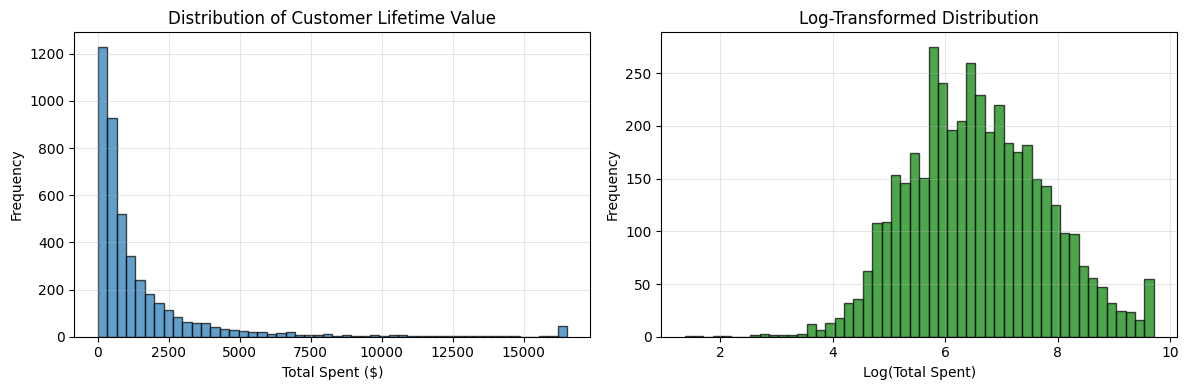

In [158]:
#check target distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Customer Lifetime Value')
plt.xlabel('Total Spent ($)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(np.log1p(y), bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title('Log-Transformed Distribution')
plt.xlabel('Log(Total Spent)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [159]:
# 5. split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} customers ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} customers ({len(X_test)/len(X)*100:.1f}%)")

Training set: 3465 customers (80.0%)
Test set: 867 customers (20.0%)


In [160]:
# 6. train model

# train random forest regerssor
print("Training Random Forest model...")

model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=15,          # Maximum tree depth
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in a leaf
    random_state=42,
    n_jobs=-1,             # Use all CPU cores
    verbose=1
)

model.fit(X_train, y_train)
print("Model trained successfully!")

Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s


Model trained successfully!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [161]:
#7 . evaluate model

#make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Model Performance Metrics:")
print("=" * 40)
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse:.2f}")
print(f"R² Score:                       {r2:.4f}")
print(f"Accuracy (R² * 100):            {r2*100:.1f}%")
print(f"Mean Absolute % Error (MAPE):   {mape:.1f}%")

Model Performance Metrics:
Mean Absolute Error (MAE):     $244.38
Root Mean Square Error (RMSE): $590.57
R² Score:                       0.9527
Accuracy (R² * 100):            95.3%
Mean Absolute % Error (MAPE):   17.3%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


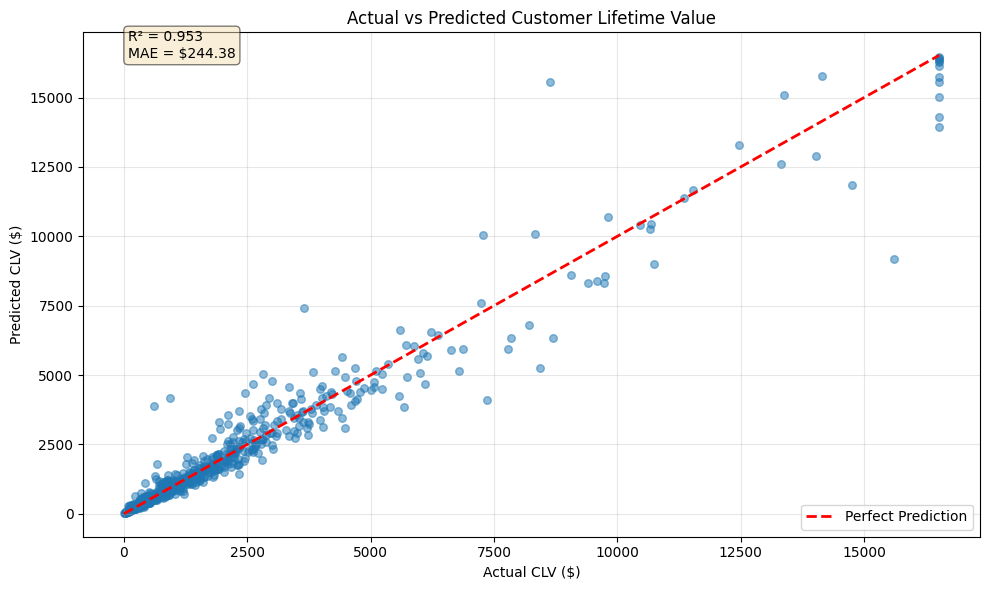

In [162]:
#actual vs predicted plot
plt.figure(figsize=(10, 6))

#scatter plot
plt.scatter(y_test, y_pred, alpha=0.5, s=30)

# Perfect prediction line
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual CLV ($)')
plt.ylabel('Predicted CLV ($)')
plt.title('Actual vs Predicted Customer Lifetime Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = ${mae:.2f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [163]:
#8. feature importance
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(importance_df)


Feature Importance:
                      Feature  Importance
8              total_quantity    0.898870
3              avg_unit_price    0.057878
0                   frequency    0.009194
5               lifespan_days    0.008886
1                     recency    0.007521
4             avg_transaction    0.006186
2                avg_quantity    0.005888
7         purchases_per_month    0.003947
6  avg_days_between_purchases    0.001629


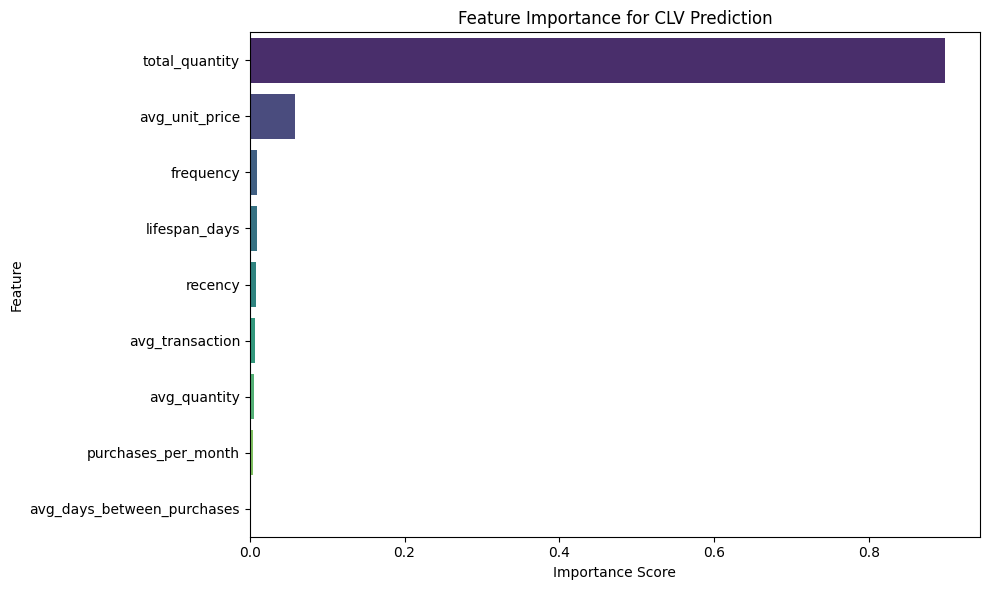

In [164]:
# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for CLV Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [165]:
# 9. create value categories

#predict for all customers
customer_features['predicted_clv'] = model.predict(X)

bins = [
    0, 
    customer_features['predicted_clv'].quantile(0.25),
    customer_features['predicted_clv'].quantile(0.5),
    customer_features['predicted_clv'].quantile(0.75),
    float('inf')
]
labels = ['Low Value', 'Medium Value', 'High Value', 'VIP']

customer_features['value_category'] = pd.cut(
    customer_features['predicted_clv'], 
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("\nCustomer Value Distribution:")
value_counts = customer_features['value_category'].value_counts()
print(value_counts)

print("\nPercentage:")
percentages = (value_counts / len(customer_features) * 100).round(1)
for category, pct in percentages.items():
    print(f"  {category}: {pct}%")


Customer Value Distribution:
value_category
Low Value       1083
Medium Value    1083
High Value      1083
VIP             1083
Name: count, dtype: int64

Percentage:
  Low Value: 25.0%
  Medium Value: 25.0%
  High Value: 25.0%
  VIP: 25.0%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


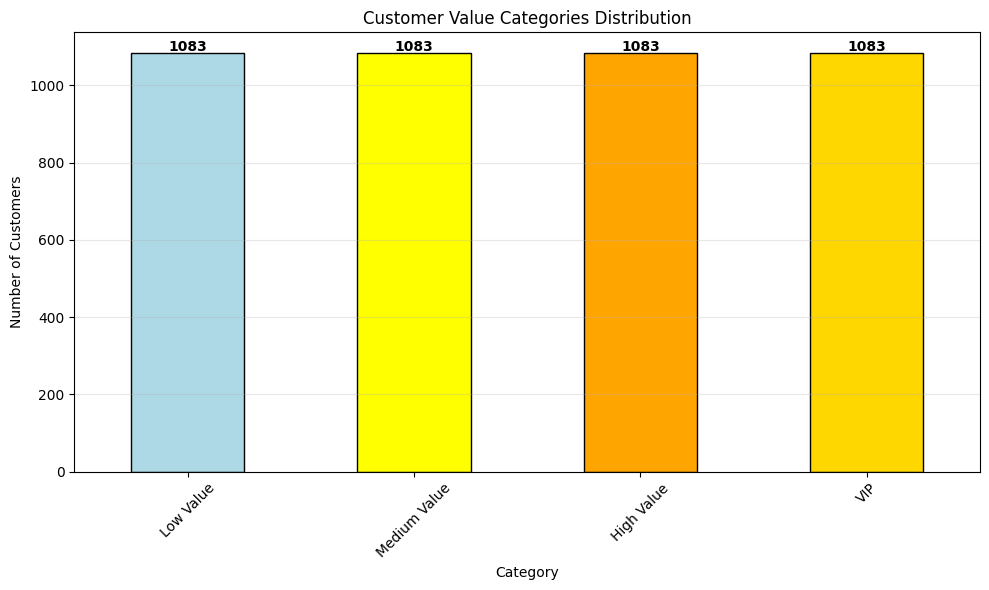

In [166]:
#visualize categories
plt.figure(figsize=(10, 6))

colors = ['lightblue', 'yellow', 'orange', 'gold']
value_counts.sort_index().plot(kind='bar', color=colors, edgecolor='black')

plt.title('Customer Value Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

for i, v in enumerate(value_counts.sort_index()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [167]:
#save model and results
joblib.dump(model, 'models/clv_model.pkl')
print("Model saved to 'models/clv_model.pkl'")

Model saved to 'models/clv_model.pkl'


In [168]:
predictions_to_save = customer_features[['CustomerID', 'predicted_clv', 'value_category']]
predictions_to_save.to_csv('clv_predictions.csv', index=False)
print("Predictions saved to 'clv_predictions.csv'")

Predictions saved to 'clv_predictions.csv'


In [169]:
customer_features.to_csv('customer_features_complete.csv', index=False)
print("Complete customer features saved")

Complete customer features saved


In [170]:
#report

print("\n" + "="*40)
print("CLV PREDICTION SUMMARY REPORT")
print("="*40)
print(f"Total customers analyzed: {len(customer_features)}")
print(f"Model R² Score: {r2:.4f} ({r2*100:.1f}% accuracy)")
print(f"Average prediction error: ${mae:.2f}")
print(f"Total predicted customer value: ${customer_features['predicted_clv'].sum():,.2f}")
print(f"Average predicted CLV: ${customer_features['predicted_clv'].mean():.2f}")


CLV PREDICTION SUMMARY REPORT
Total customers analyzed: 4332
Model R² Score: 0.9527 (95.3% accuracy)
Average prediction error: $244.38
Total predicted customer value: $6,585,880.11
Average predicted CLV: $1520.29
